<a href="https://colab.research.google.com/github/ahamonk/Enterprise-Knowledge-Silos/blob/main/Spam_Email_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q pandas scikit-learn nltk

In [2]:
import pandas as pd
import numpy as np

import nltk

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [3]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip

!unzip smsspamcollection.zip

--2026-07-08 10:13:57--  https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘smsspamcollection.zip’

smsspamcollection.z     [  <=>               ] 198.65K   409KB/s    in 0.5s    

2026-07-08 10:13:58 (409 KB/s) - ‘smsspamcollection.zip’ saved [203415]

Archive:  smsspamcollection.zip
  inflating: SMSSpamCollection       
  inflating: readme                  


In [4]:
df = pd.read_csv(
    "SMSSpamCollection",
    sep="\t",
    names=["label", "message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [6]:
df["label"].value_counts()

,count
label,
ham,4825
spam,747


In [7]:
df.isnull().sum()

,0
label,0
message,0


In [8]:
df["label"] = df["label"].map({
    "ham":0,
    "spam":1
})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
X = df["message"]

y = df["label"]

In [42]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

In [43]:
vectorizer = TfidfVectorizer(
    stop_words="english"
)

X_train = vectorizer.fit_transform(X_train)

X_test = vectorizer.transform(X_test)

In [44]:
model = MultinomialNB()

model.fit(
    X_train,
    y_train
)

MultinomialNB()

In [45]:
predictions = model.predict(X_test)

In [46]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.97847533632287


In [47]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.84      0.91       149

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



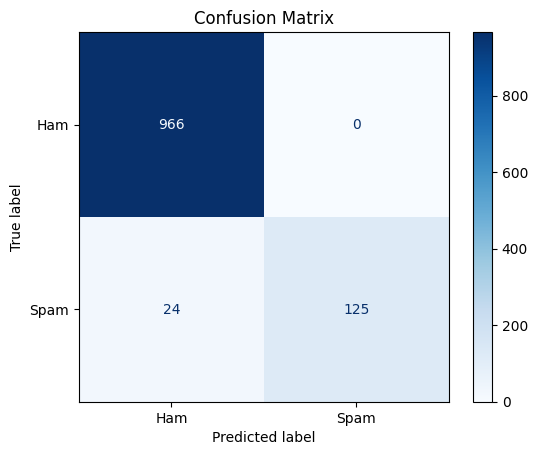

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=["Ham", "Spam"],
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

In [49]:
while True:

    message = input("Enter a message (type 'quit' to stop): ")

    if message.lower() == "quit":
        break

    vector = vectorizer.transform([message])

    prediction = model.predict(vector)

    probability = model.predict_proba(vector)

    if prediction[0] == 1:
        print("Spam")
    else:
        print("Not Spam")

    print(
        "Confidence:",
        round(np.max(probability)*100,2),
        "%"
    )

    print()

Enter a message (type 'quit' to stop): congratulations! you have won $100
Spam
Confidence: 81.48 %

Enter a message (type 'quit' to stop): quit


In [36]:
!pip install -q gradio

In [22]:
import gradio as gr
import numpy as np

In [50]:
def classify_message(message):

    if not message.strip():
        return (
            "⚠️ Please enter a message.",
            "0%",
            {"Ham": 0, "Spam": 0}
        )

    vector = vectorizer.transform([message])

    prediction = model.predict(vector)[0]
    probabilities = model.predict_proba(vector)[0]

    ham_prob = float(probabilities[0])
    spam_prob = float(probabilities[1])

    confidence = max(ham_prob, spam_prob) * 100

    if prediction == 1:
        result = "🚨 SPAM"
    else:
        result = "✅ NOT SPAM"

    return (
        result,
        f"{confidence:.2f}%",
        {
            "Ham": ham_prob,
            "Spam": spam_prob
        }
    )

In [51]:
with gr.Blocks(theme=gr.themes.Soft(), title="Spam Message Classifier") as demo:

    gr.Markdown(
        """
        # 📧 Spam Message Classifier

        Detect whether an SMS or email message is **Spam** or **Legitimate**.

        **Model Used**
        - TF-IDF Vectorization
        - Multinomial Naive Bayes
        """
    )

    with gr.Row():

        message = gr.Textbox(
            label="Enter Message",
            lines=8,
            placeholder="Type or paste your message here..."
        )

    classify_btn = gr.Button(
        "🔍 Classify Message",
        variant="primary"
    )

    gr.Markdown("---")

    with gr.Row():

        prediction = gr.Textbox(
            label="Prediction",
            interactive=False
        )

        confidence = gr.Textbox(
            label="Confidence",
            interactive=False
        )

    probabilities = gr.Label(
        label="Prediction Probabilities"
    )

    classify_btn.click(
        fn=classify_message,
        inputs=message,
        outputs=[
            prediction,
            confidence,
            probabilities
        ]
    )

/tmp/ipykernel_653/1476813097.py:1: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title="Spam Message Classifier") as demo:


In [52]:
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://50cd765f8d4ad1b170.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
